# **Comparative Analysis of Tripartite Networks**

# Import Libraries and Configurations

In [1]:
import ast
import os
import sys
from itertools import combinations, permutations

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib_venn import venn2, venn3
from venn import venn

# Add project root to Python's path
sys.path.append(os.path.abspath(os.path.join('..')))

from config import (
    DATA_SUBDIRS,
    NETWORK_DATA_DIRS,
)

# Remove the HER2-enriched group from the analysis
GROUPS = DATA_SUBDIRS.copy()
GROUPS.remove('her2-enriched')

# Metrics calculated in the individual analysis
METRICS = [
    # 'degree', 
    'betweenness_centrality', 
    'closeness_centrality', 
    'degree_centrality', 
    'redundancy_coefficient', 
    'pathway_reach',
    'functional_impact',
]

# Thresholds for node classification
LOWER_NODE_RANKING_THRESHOLD = 0.25
UPPER_NODE_RANKING_THRESHOLD = 0.50
JACCARD_NODE_RANKING_THRESHOLD = 0.25

# Functions

## Classification of Node Specificity

### Rank Nodes by Metric Values

In [2]:
def rank_nodes_by_metric_values(
    df_nodes, partition, metric, ascending_order=False
):
    # Create a dictionary to store ranked lists of nodes
    ranked_nodes = dict()

    # Iterate over the groups
    groups = df_nodes['group'].unique()
    for group in groups:
        # Sort the nodes according to their metric values
        df_metric_ranked = df_nodes \
            .query('(group == @group) and (type == @partition)') \
            .dropna(subset=metric) \
            .sort_values(by=metric, ascending=ascending_order)
        
        # Store the ranked list of nodes on the dictionary
        ranked_nodes[group] = df_metric_ranked['id'].to_list()
    
    return ranked_nodes

### Classify the Specificity of the Nodes

In [3]:
def classify_node_specifity(ranked_nodes):
    # Create dictionaries to store specific and non-specific nodes
    specific = dict()
    non_specific = dict()

    # Iterate over the groups
    groups = ranked_nodes.keys()
    for group1 in groups:
        # Select the ranked nodes related to the group
        group1_nodes = ranked_nodes[group1]

        # Iterate over nodes within the lower threshold
        lower_threshold = int(
            LOWER_NODE_RANKING_THRESHOLD 
            * len(group1_nodes)
        )
        for node in group1_nodes[:lower_threshold]:
            # Create a list to store the groups where the node is important
            node_groups = [group1]

            # Iterate over the other groups
            for group2 in groups:
                if group2 == group1:
                    continue

                # Select the ranked nodes related to the other group
                group2_nodes = ranked_nodes[group2]

                # Check if the node is specific to the first group
                upper_threshold = int(
                    UPPER_NODE_RANKING_THRESHOLD 
                    * len(group2_nodes)
                )
                if node in group2_nodes[:upper_threshold]:
                    node_groups.append(group2)

            # Store the node as specific or non-specific
            if len(node_groups) == 1:
                specific[node] = sorted(node_groups)
            else:
                non_specific[node] = sorted(node_groups)
        
        # Create a dictionary to store nodes by specificity
        node_specificity = dict()
        node_specificity['specific'] = specific
        node_specificity['non_specific'] = non_specific

    return node_specificity

### Classify Non-specific Nodes

In [4]:
def classify_non_specific_nodes(df_edges, node_specificity):
    # Create dictionaries to store common and differential nodes
    common = dict()
    differential = dict()
    
    # Check if the nodes are in the `source` or `target` column
    non_specific = node_specificity['non_specific']
    sample_node = list(non_specific.keys())[0]
    edge_list = df_edges \
        .query('source == @sample_node') \
        ['target'].to_list()

    if len(edge_list) > 0:
        col1 = 'source'
        col2 = 'target'
    else:
        col1 = 'target'
        col2 = 'source'

    # Iterate over non-specific nodes
    for node in non_specific.keys():
        # Groups where the node is "important"
        groups = non_specific[node]

        # Select the edges that enclose the node
        df_node_edges = df_edges[df_edges[col1] == node]

        # Create a list to store the similarity between groups
        similarity = list()
        is_differential = True

        # Iterate over the possible group combinations
        for g1, g2 in combinations(groups, 2):
            # Define the neighborhood in each group
            g1_neighbors = set(
                df_node_edges.query('group == @g1')[col2].to_list()
            )
            g2_neighbors = set(
                df_node_edges.query('group == @g2')[col2].to_list()
            )

            # Calculate the Jaccard similarity between neighborhoods
            intersection = g1_neighbors & g2_neighbors
            union = g1_neighbors | g2_neighbors
            jaccard_index = len(intersection) / len(union)

            # Check if the combination characterizes a common node
            if jaccard_index >= JACCARD_NODE_RANKING_THRESHOLD:
                is_differential = False

            # Store the similarity between the two groups
            similarity.append((g1, g2, round(jaccard_index, 3)))

        # Store the node as differential or common
        if is_differential:
            differential[node] = similarity
        else:
            common[node] = similarity

    # Store the two new node specificity classifications
    node_specificity['common'] = common
    node_specificity['differential'] = differential

    return node_specificity

### Print Node Classification

In [5]:
def print_node_classification(analyzed_networks):
    nsm = dict()

    df_nodes = analyzed_networks['nodes'] \
        .query('type != "Pathway"') \
        .drop_duplicates(ignore_index=True) \
        .copy()
    df_edges = analyzed_networks['edges'] \
        .dropna(subset='correlation') \
        .drop_duplicates(ignore_index=True) \
        .copy()
        
    base_title = f'Tripartite Networks'
        
    # Iterate over network partitions
    for partition in ['MicroRNA']:
        main_title = f'{base_title} - {partition} Nodes'
        print(f'===== {main_title} =====')

        # Iterate over topological metrics
        for metric in METRICS:
            if partition == 'Messenger RNA':
                if metric in METRICS[-2:]:
                    continue

            subtitle = (metric.replace('_', ' ')).title()
            
            # Iterate over the different rankings
            # for ascending_order in [False, True]:
            if metric == 'redundancy_coefficient':
                ascending_order = True
            else:
                ascending_order = False

            ranking = 'Ascending' if ascending_order else 'Descending'
            print(f'\n##### {subtitle} - {ranking} Ranking #####')
            
            # Rank the nodes according to the metric values
            ranked_nodes = rank_nodes_by_metric_values(
                df_nodes, partition, metric, ascending_order
            )

            # Classify the nodes as specific or non-specific
            node_specificity = classify_node_specifity(ranked_nodes)

            # Classify the non-specific nodes as common or differential
            if node_specificity['non_specific']:
                node_specificity = classify_non_specific_nodes(
                    df_edges, node_specificity
                )
            
            nsm[metric] = node_specificity

            # Iterate over the classifications
            for classification in node_specificity.keys():
                # Print the nodes and their related groups
                elements = node_specificity[classification]
                print(f'\n> {classification} = {len(elements)}')

                for node in sorted(elements.keys()):
                    print(f'- {node}: {elements[node]}')

        print()

    return nsm

# Load the Data

In [6]:
# Create a dictionary to store DataFrames related to network analysis
analyzed_networks = dict()
analyzed_networks['edges'] = pd.DataFrame()
analyzed_networks['nodes'] = pd.DataFrame()

# Iterate over the groups
for group in GROUPS:    
    group_dir = (group.lower()).replace(' ', '-')
    dir_path = NETWORK_DATA_DIRS['processed'][group_dir]

    edges_file = 'tripartite-network-edges.csv'
    df_edges = pd.read_csv(os.path.join(dir_path, edges_file))
    df_edges['group'] = group

    nodes_file = 'tripartite-network-nodes-with-metrics.csv'
    df_nodes = pd.read_csv(os.path.join(dir_path, nodes_file))
    df_nodes['group'] = group

    # Concatenate the edges and nodes of the group to the others
    analyzed_networks['edges'] = pd.concat(
        objs=[analyzed_networks['edges'], df_edges], 
        ignore_index=True
    )
    analyzed_networks['nodes'] = pd.concat(
        objs=[analyzed_networks['nodes'], df_nodes], 
        ignore_index=True
    )

# Only Cancer

## Data Preparation

In [7]:
# Create a dictionary to store data only about cancer
cancer_networks = dict()

# Iterate over the network elements
for element in ['edges', 'nodes']:
    cancer_networks[element] = \
        analyzed_networks[element] \
        .query('group != "normal"') \
        .reset_index(drop=True)

## Node Classification

In [8]:
# Print the classification of the nodes according to the metric values
nsm = print_node_classification(cancer_networks)

===== Tripartite Networks - MicroRNA Nodes =====

##### Betweenness Centrality - Descending Ranking #####

> specific = 14
- hsa-miR-130b-3p: ['luminal-b']
- hsa-miR-148a-3p: ['luminal-b']
- hsa-miR-15b-5p: ['luminal-b']
- hsa-miR-182-5p: ['basal-like']
- hsa-miR-193b-3p: ['luminal-b']
- hsa-miR-24-3p: ['luminal-b']
- hsa-miR-27b-3p: ['luminal-b']
- hsa-miR-29a-3p: ['luminal-b']
- hsa-miR-29c-3p: ['luminal-b']
- hsa-miR-301a-3p: ['luminal-a']
- hsa-miR-30b-5p: ['luminal-b']
- hsa-miR-33a-5p: ['luminal-b']
- hsa-miR-34a-5p: ['luminal-b']
- hsa-miR-98-5p: ['luminal-b']

> non_specific = 9
- hsa-miR-106a-5p: ['basal-like', 'luminal-b']
- hsa-miR-106b-5p: ['basal-like', 'luminal-a', 'luminal-b']
- hsa-miR-141-3p: ['basal-like', 'luminal-a', 'luminal-b']
- hsa-miR-18a-5p: ['basal-like', 'luminal-b']
- hsa-miR-200b-3p: ['basal-like', 'luminal-a']
- hsa-miR-200c-3p: ['basal-like', 'luminal-b']
- hsa-miR-25-3p: ['basal-like', 'luminal-b']
- hsa-miR-29b-3p: ['luminal-a', 'luminal-b']
- hsa-miR-

In [9]:
nsm

{'betweenness_centrality': {'specific': {'hsa-miR-182-5p': ['basal-like'],
   'hsa-miR-301a-3p': ['luminal-a'],
   'hsa-miR-27b-3p': ['luminal-b'],
   'hsa-miR-33a-5p': ['luminal-b'],
   'hsa-miR-30b-5p': ['luminal-b'],
   'hsa-miR-34a-5p': ['luminal-b'],
   'hsa-miR-15b-5p': ['luminal-b'],
   'hsa-miR-148a-3p': ['luminal-b'],
   'hsa-miR-29c-3p': ['luminal-b'],
   'hsa-miR-24-3p': ['luminal-b'],
   'hsa-miR-130b-3p': ['luminal-b'],
   'hsa-miR-193b-3p': ['luminal-b'],
   'hsa-miR-98-5p': ['luminal-b'],
   'hsa-miR-29a-3p': ['luminal-b']},
  'non_specific': {'hsa-miR-96-5p': ['basal-like', 'luminal-a', 'luminal-b'],
   'hsa-miR-106b-5p': ['basal-like', 'luminal-a', 'luminal-b'],
   'hsa-miR-106a-5p': ['basal-like', 'luminal-b'],
   'hsa-miR-200b-3p': ['basal-like', 'luminal-a'],
   'hsa-miR-29b-3p': ['luminal-a', 'luminal-b'],
   'hsa-miR-141-3p': ['basal-like', 'luminal-a', 'luminal-b'],
   'hsa-miR-200c-3p': ['basal-like', 'luminal-b'],
   'hsa-miR-18a-5p': ['basal-like', 'luminal-b'

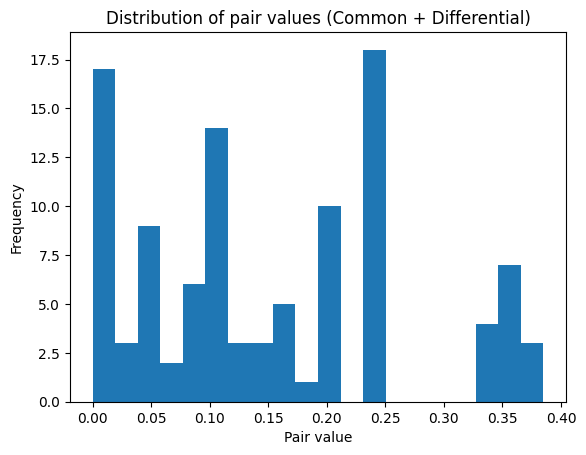

In [10]:
import matplotlib.pyplot as plt

# your dictionary
data = nsm   # replace with your variable name

# collect values from both "common" and "differential"
values = [
    v
    for metric in data.values()
    for group in ["common", "differential"]
    for pairs in metric.get(group, {}).values()
    for _, _, v in pairs
]

# plot histogram
plt.figure()
plt.hist(values, bins=20)
plt.xlabel("Pair value")
plt.ylabel("Frequency")
plt.title("Distribution of pair values (Common + Differential)")
plt.show()

In [11]:
import numpy as np

vals = np.sort(values)
gaps = np.diff(vals)

idx = np.argmax(gaps)
threshold = (vals[idx] + vals[idx+1]) / 2

print("Split value:", threshold)

Split value: 0.2915


In [12]:
def filter_pairs_inplace(data, threshold=JACCARD_NODE_RANKING_THRESHOLD):
    for metric in data:
        for category in ["common", "differential"]:
            if category not in data[metric]:
                continue

            new_mirnas = {}

            for mirna, pairs in data[metric][category].items():
                if category == "common":
                    kept = [p for p in pairs if p[2] >= threshold]
                else:
                    kept = [p for p in pairs if p[2] < threshold]

                if kept:
                    new_mirnas[mirna] = kept

            data[metric][category] = new_mirnas

    return data

In [13]:
nsm = filter_pairs_inplace(nsm)
nsm

{'betweenness_centrality': {'specific': {'hsa-miR-182-5p': ['basal-like'],
   'hsa-miR-301a-3p': ['luminal-a'],
   'hsa-miR-27b-3p': ['luminal-b'],
   'hsa-miR-33a-5p': ['luminal-b'],
   'hsa-miR-30b-5p': ['luminal-b'],
   'hsa-miR-34a-5p': ['luminal-b'],
   'hsa-miR-15b-5p': ['luminal-b'],
   'hsa-miR-148a-3p': ['luminal-b'],
   'hsa-miR-29c-3p': ['luminal-b'],
   'hsa-miR-24-3p': ['luminal-b'],
   'hsa-miR-130b-3p': ['luminal-b'],
   'hsa-miR-193b-3p': ['luminal-b'],
   'hsa-miR-98-5p': ['luminal-b'],
   'hsa-miR-29a-3p': ['luminal-b']},
  'non_specific': {'hsa-miR-96-5p': ['basal-like', 'luminal-a', 'luminal-b'],
   'hsa-miR-106b-5p': ['basal-like', 'luminal-a', 'luminal-b'],
   'hsa-miR-106a-5p': ['basal-like', 'luminal-b'],
   'hsa-miR-200b-3p': ['basal-like', 'luminal-a'],
   'hsa-miR-29b-3p': ['luminal-a', 'luminal-b'],
   'hsa-miR-141-3p': ['basal-like', 'luminal-a', 'luminal-b'],
   'hsa-miR-200c-3p': ['basal-like', 'luminal-b'],
   'hsa-miR-18a-5p': ['basal-like', 'luminal-b'

In [14]:
from collections import defaultdict

def restructure_with_metrics(data):
    # new_dict[classification][group][mirna] = set(metrics)
    new_dict = defaultdict(lambda: defaultdict(lambda: defaultdict(set)))

    for metric, groups in data.items():
        for group, mirnas in groups.items():
            for mirna, values in mirnas.items():

                # Case 1: specific / non_specific
                if isinstance(values, list) and values and isinstance(values[0], str):
                    for classification in values:
                        new_dict[classification][group][mirna].add(metric)

                # Case 2: common / differential
                elif isinstance(values, list) and values and isinstance(values[0], tuple):
                    for class1, class2, _ in values:
                        new_dict[class1][group][mirna].add(metric)
                        new_dict[class2][group][mirna].add(metric)

    # Convert sets to sorted lists
    return {
        classification: {
            group: {
                mirna: sorted(list(metrics))
                for mirna, metrics in mirnas.items()
            }
            for group, mirnas in groups.items()
        }
        for classification, groups in new_dict.items()
    }

In [15]:
res = restructure_with_metrics(nsm)
res

{'basal-like': {'specific': {'hsa-miR-182-5p': ['betweenness_centrality'],
   'hsa-miR-128-3p': ['redundancy_coefficient'],
   'hsa-miR-18a-5p': ['redundancy_coefficient'],
   'hsa-miR-27a-3p': ['redundancy_coefficient'],
   'hsa-miR-15b-5p': ['redundancy_coefficient'],
   'hsa-let-7e-5p': ['pathway_reach'],
   'hsa-miR-92a-3p': ['pathway_reach'],
   'hsa-miR-222-3p': ['functional_impact', 'pathway_reach'],
   'hsa-miR-93-5p': ['functional_impact', 'pathway_reach'],
   'hsa-miR-196a-5p': ['functional_impact', 'pathway_reach'],
   'hsa-miR-335-5p': ['pathway_reach'],
   'hsa-miR-23a-3p': ['functional_impact'],
   'hsa-let-7c-5p': ['functional_impact']},
  'non_specific': {'hsa-miR-96-5p': ['betweenness_centrality',
    'closeness_centrality',
    'degree_centrality',
    'functional_impact',
    'pathway_reach'],
   'hsa-miR-106b-5p': ['betweenness_centrality',
    'closeness_centrality',
    'degree_centrality',
    'functional_impact',
    'pathway_reach'],
   'hsa-miR-106a-5p': ['bet

In [16]:
cancer_networks['edges']

,source,target,mirtarbase,correlation,qvalue,group
0,hsa-miR-182-5p,RAB27A,NaN,-0.564,0.000000,basal-like
1,hsa-miR-18a-5p,ORAI3,MIRT050737,-0.545,0.000000,basal-like
2,hsa-miR-18a-5p,ZBTB4,NaN,-0.532,0.001000,basal-like
3,hsa-miR-96-5p,RAB27A,NaN,-0.496,0.004000,basal-like
4,hsa-miR-106b-5p,ATXN1,MIRT441140,-0.495,0.004000,basal-like
...,...,...,...,...,...,...
1694,CALN1,KEGG:04520,NaN,NaN,0.046142,luminal-b
1695,NAV1,KEGG:04520,NaN,NaN,0.046142,luminal-b
1696,KCNJ2,KEGG:04520,NaN,NaN,0.046142,luminal-b
1697,ZC2HC1C,KEGG:04520,NaN,NaN,0.046142,luminal-b


In [17]:
cancer_networks['nodes']

,id,label,type,module_id,connected_component_id,is_in_largest_component,betweenness_centrality,closeness_centrality,degree_centrality,redundancy_coefficient,paths,pathway_reach,functional_impact,group
0,hsa-miR-182-5p,hsa-miR-182-5p,MicroRNA,1.0,0,1,0.156133,0.259864,0.114094,0.044118,"[('ANKRD44', 'KEGG:04010')]",0.076923,0.343706,basal-like
1,hsa-miR-18a-5p,hsa-miR-18a-5p,MicroRNA,1.0,0,1,0.107650,0.282127,0.040268,0.000000,"[('ORAI3', 'KEGG:04020'), ('PRKACB', 'KEGG:040...",0.153846,0.438192,basal-like
2,hsa-miR-96-5p,hsa-miR-96-5p,MicroRNA,1.0,0,1,0.497522,0.375246,0.214765,0.030242,"[('CCND2', 'KEGG:05202'), ('CCND2', 'KEGG:0520...",1.000000,0.392891,basal-like
3,hsa-miR-106b-5p,hsa-miR-106b-5p,MicroRNA,1.0,0,1,0.491275,0.384306,0.268456,0.042308,"[('KLF3', 'KEGG:05202'), ('RASGRF2', 'KEGG:040...",0.846154,0.385705,basal-like
4,hsa-miR-221-3p,hsa-miR-221-3p,MicroRNA,1.0,5,0,NaN,NaN,NaN,NaN,"[('ERBB3', 'KEGG:04020'), ('ERBB3', 'KEGG:0152...",0.307692,0.473942,basal-like
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1329,KEGG:04720,Long-term potentiation,Pathway,0.0,0,1,0.004420,0.363057,0.056075,0.866667,NaN,NaN,NaN,luminal-b
1330,KEGG:05202,Transcriptional misregulation in cancer,Pathway,0.0,0,1,0.046321,0.448819,0.102804,0.472727,NaN,NaN,NaN,luminal-b
1331,KEGG:04140,Autophagy - animal,Pathway,0.0,0,1,0.046665,0.460916,0.093458,0.444444,NaN,NaN,NaN,luminal-b
1332,KEGG:05225,Hepatocellular carcinoma,Pathway,0.0,0,1,0.014950,0.468493,0.093458,0.933333,NaN,NaN,NaN,luminal-b


In [18]:
df_groups = dict()

for group in res.keys():
    group_res = res[group]
    df_groups[group] = dict()

    df_group_edges = cancer_networks['edges'] \
        .query(f'group == "{group}"')
    
    df_group_nodes = cancer_networks['nodes'] \
        .query(f'group == "{group}"')

    for classif in group_res.keys():
        if classif == 'non_specific':
            continue

        classif_group_res = group_res[classif]
        df_groups[group][classif] = dict()

        df_classif_mirs = pd.DataFrame(
            data=list(classif_group_res.items()), 
            columns=['id', 'metrics']
        )

        df_classif_mirs['total_metrics'] = \
            df_classif_mirs['metrics'].apply(
                lambda x: int(len(x))
            )
        df_classif_mirs['metrics'] = \
            df_classif_mirs['metrics'].apply(
                lambda x: '; '.join(x) if isinstance(x, list) else x
            )

        # microRNA-messenger RNA edges
        df_classif_edges = df_classif_mirs \
            .merge(
                right=df_group_edges,
                how='inner',
                left_on='id',
                right_on='source',
            )  \
            [['source', 'target']] \
            .rename(columns={
                'source': 'mir',
                'target': 'mediator',
            })
        
        # microRNA-messenger RNA-pathway paths
        df_classif_edges = df_classif_edges \
            .merge(
                right=df_group_edges,
                how='inner',
                left_on='mediator',
                right_on='source',
            ) \
            [['mir', 'mediator', 'target']] \
            .rename(columns={
                'source': 'target',
                'mir': 'source',
            })
        
        # microRNAs
        df_classif_source_nodes = df_classif_edges \
            .merge(
                right=df_group_nodes,
                how='inner',
                left_on='source',
                right_on='id',
            ) \
            .drop(columns=['source', 'mediator', 'target']) \
            .merge(
                right=df_classif_mirs,
                how='left',
                on='id',
            )
        
        # messenger RNAs
        df_classif_mediator_nodes = df_classif_edges \
            .merge(
                right=df_group_nodes,
                how='inner',
                left_on='mediator',
                right_on='id',
            ) \
            .drop(columns=['source', 'mediator', 'target'])
        
        # pathways
        df_classif_target_nodes = df_classif_edges \
            .merge(
                right=df_group_nodes,
                how='inner',
                left_on='target',
                right_on='id',
            ) \
            .drop(columns=['source', 'mediator', 'target'])
            
        # nodes
        df_classif_nodes = pd.concat([
            df_classif_source_nodes,
            df_classif_mediator_nodes,
            df_classif_target_nodes,
        ])
        
        # aggregate microRNA-pathway by mediators
        df_classif_edges_agg = df_classif_edges \
            .groupby(['source', 'target']) \
            .agg(
                mediators = \
                    pd.NamedAgg(column='mediator', aggfunc=list), 
                total_mediators = \
                    pd.NamedAgg(column='mediator', aggfunc='nunique')
            ) \
            .reset_index() \
            .sort_values(
                by='total_mediators', ascending=False, ignore_index=True
            )

        df_classif_edges_agg['mediators'] = \
            df_classif_edges_agg['mediators'] \
                .apply(
                lambda x: '; '.join(x) if isinstance(x, list) else x
            )
        
        df_classif_analysis = df_classif_edges_agg \
            .merge(
                right=df_classif_nodes,
                how='left',
                left_on='source',
                right_on='id',
            ) \
            [[
                'metrics', 
                'total_metrics', 
                'source', 
                'target', 
                'mediators', 
                'total_mediators', 
            ]] \
            .drop_duplicates(ignore_index=True)
        
        df_classif_analysis = df_classif_analysis \
            .merge(
                right=df_classif_nodes[['id', 'label']],
                how='left',
                left_on='target',
                right_on='id',
            ) \
            .rename(columns={'label': 'target_label'}) \
            [[
                'metrics', 
                'total_metrics', 
                'source', 
                'target', 
                'target_label', 
                'mediators', 
                'total_mediators', 
            ]] \
            .drop_duplicates(ignore_index=True) \
            .sort_values(
                by='total_metrics', ascending=False, ignore_index=True
            )
    
        print(group, classif)
        print(df_classif_analysis)

        df_groups[group][classif]['edges'] = df_classif_edges_agg
        df_groups[group][classif]['nodes'] = df_classif_nodes
        df_groups[group][classif]['analysis'] = df_classif_analysis

basal-like specific
                             metrics  total_metrics           source  \
0   functional_impact; pathway_reach            2.0    hsa-miR-93-5p   
1   functional_impact; pathway_reach            2.0   hsa-miR-222-3p   
2   functional_impact; pathway_reach            2.0   hsa-miR-222-3p   
3   functional_impact; pathway_reach            2.0  hsa-miR-196a-5p   
4   functional_impact; pathway_reach            2.0  hsa-miR-196a-5p   
5   functional_impact; pathway_reach            2.0  hsa-miR-196a-5p   
6   functional_impact; pathway_reach            2.0   hsa-miR-222-3p   
7   functional_impact; pathway_reach            2.0   hsa-miR-222-3p   
8   functional_impact; pathway_reach            2.0    hsa-miR-93-5p   
9   functional_impact; pathway_reach            2.0    hsa-miR-93-5p   
10  functional_impact; pathway_reach            2.0   hsa-miR-222-3p   
11  functional_impact; pathway_reach            2.0   hsa-miR-222-3p   
12  functional_impact; pathway_reach        

In [19]:
for group in df_groups.keys():
    group_dir = (group.lower()).replace(' ', '-')
    dir_path = NETWORK_DATA_DIRS['processed'][group_dir]

    for classif in df_groups[group].keys():
        for entity in df_groups[group][classif].keys():
            file_name = f'{classif}_{entity}.csv'
            df_groups[group][classif][entity].to_csv(
                os.path.join(dir_path, file_name), index=False
            )

# 2-Layer

In [20]:
import pandas as pd
import plotly.graph_objects as go

def two_layer_sankey(df_groups, group, classification, flag=''):
    # ===============================
    # 1. Load data
    # ===============================
    df = df_groups[group][classification]['analysis'].copy()
    
    # Split mediators and explode
    df["mediators"] = df["mediators"].str.split("; ")
    df = df.explode("mediators")

    # ===============================
    # 2. Create edge list (source → target)
    #    Each mediator becomes its own link
    # ===============================
    edges = []

    for _, row in df.iterrows():
        edges.append((
            row["source"],
            row["target_label"],
            row["mediators"],   # mediator label
            1
        ))

    edges_df = pd.DataFrame(edges, columns=["source", "target", "mediator", "value"])

    # ===============================
    # 3. Create nodes (ONLY 2 layers)
    # ===============================
    nodes = pd.unique(edges_df[["source", "target"]].values.ravel())
    node_dict = {node: i for i, node in enumerate(nodes)}

    edges_df["source_id"] = edges_df["source"].map(node_dict)
    edges_df["target_id"] = edges_df["target"].map(node_dict)

    # ===============================
    # 4. Define node positions (2 layers)
    # ===============================
    sources = df["source"].unique()
    targets = df["target_label"].unique()

    x_positions = []
    colors = []

    for node in nodes:
        if node in sources:
            x_positions.append(0.0)
            colors.append("#EF3B2C")  # miRNA
        else:
            x_positions.append(1.0)
            colors.append("#FF8000")  # pathway

    # ===============================
    # 5. Plot Sankey
    # ===============================
    fig = go.Figure(go.Sankey(
        arrangement="snap",
        node=dict(
            pad=20,
            thickness=20,
            label=nodes,
            x=x_positions,
            color=colors
        ),
        link=dict(
            source=edges_df["source_id"],
            target=edges_df["target_id"],
            value=edges_df["value"],
            label=edges_df["mediator"]  # mediator appears on hover
        )
    ))

    fig.update_layout(
        title=f"2-layer -- {group} -- {classification} miRs",
        font_size=12,
        height=700
    )

    fig.show()
    fig.write_html(f"../data/2-layer_{group}_{classification}{flag}.html")

In [21]:
# for group in df_groups.keys():
#     for classif in df_groups[group].keys():
#         two_layer_sankey(df_groups, group, classif)

# 3-Layer

In [22]:
import pandas as pd
import plotly.graph_objects as go

def three_layer_sankey(df, group, classification, flag=''):
    # ===============================
    # 1. Load data
    # ===============================
    # df = pd.read_csv("your_file.csv", sep="\t")
    df = df_groups[group][classification]['analysis'].copy()

    # Split mediators and explode
    df["mediators"] = df["mediators"].str.split("; ")
    df = df.explode("mediators")

    # ===============================
    # 2. Create edge list
    # ===============================
    edges = []

    for _, row in df.iterrows():
        edges.append((row["source"], row["mediators"], 1))
        edges.append((row["mediators"], row["target_label"], 1))

    edges_df = pd.DataFrame(edges, columns=["source", "target", "value"])
    edges_df = edges_df.groupby(["source", "target"], as_index=False).sum()

    # ===============================
    # 3. Create nodes
    # ===============================
    nodes = pd.unique(edges_df[["source", "target"]].values.ravel())
    node_dict = {node: i for i, node in enumerate(nodes)}

    edges_df["source_id"] = edges_df["source"].map(node_dict)
    edges_df["target_id"] = edges_df["target"].map(node_dict)

    # ===============================
    # 4. Define node positions (3 layers)
    # ===============================
    sources = df["source"].unique()
    mediators = df["mediators"].unique()
    targets = df["target_label"].unique()

    x_positions = []
    colors = []

    for node in nodes:
        if node in sources:
            x_positions.append(0.0)
            colors.append("#EF3B2C")
        elif node in mediators:
            x_positions.append(0.5)
            colors.append("#6BAED6")
        else:
            x_positions.append(1.0)
            colors.append("#FF8000")

    # ===============================
    # 5. Plot Sankey
    # ===============================
    fig = go.Figure(go.Sankey(
        arrangement="snap",
        node=dict(
            pad=20,
            thickness=20,
            label=nodes,
            x=x_positions,
            color=colors
        ),
        link=dict(
            source=edges_df["source_id"],
            target=edges_df["target_id"],
            value=edges_df["value"]
        )
    ))

    fig.update_layout(
        title=f"3-layer -- {group} -- {classification} miRs",
        font_size=12,
        height=700
    )

    fig.show()
    fig.write_html(f"../data/3-layer_{group}_{classification}{flag}.html")

In [23]:
# for group in df_groups.keys():
#     for classif in df_groups[group].keys():
#         three_layer_sankey(df_groups, group, classif)

In [24]:
# df_groups_filtered = df_groups.copy()

# for group in df_groups_filtered.keys():
#     for classif in df_groups_filtered[group].keys():
#         df_groups_filtered[group][classif]['analysis'] = \
#             df_groups_filtered[group][classif]['analysis'] \
#             .query(
#                 '(target_label != "Transcriptional misregulation in cancer") '
#                 +  '& (target_label != "Pathways in cancer")'
#             )
        
#         two_layer_sankey(df_groups_filtered, group, classif, '_filtered-pathways')

In [25]:
df_groups_filtered = df_groups.copy()

for group in df_groups_filtered.keys():
    for classif in df_groups_filtered[group].keys():
        df_groups_filtered[group][classif]['analysis'] = \
            df_groups_filtered[group][classif]['analysis'] \
            .query(
                '(target_label != "Transcriptional misregulation in cancer") '
                +  '& (target_label != "Pathways in cancer")'
            )
        
        three_layer_sankey(df_groups_filtered, group, classif, '_filtered-pathways')

In [38]:
df_groups_filtered['basal-like']['common']['analysis'] \
    ['target_label'] \
    .drop_duplicates() \
    .sort_values(ignore_index=True)

0                     Calcium signaling pathway
1     EGFR tyrosine kinase inhibitor resistance
2                          Endocrine resistance
3                        FoxO signaling pathway
4                                        Glioma
5                  Longevity regulating pathway
6                        MAPK signaling pathway
7                       Proteoglycans in cancer
8                         Ras signaling pathway
9                     Th17 cell differentiation
10                        p53 signaling pathway
Name: target_label, dtype: object

In [ ]:
df_groups_filtered['basal-like']['differential']['analysis'] \
    ['target_label'] \
    .drop_duplicates() \
    .sort_values(ignore_index=True) 

0                     Calcium signaling pathway
1     EGFR tyrosine kinase inhibitor resistance
2                          Endocrine resistance
3                        FoxO signaling pathway
4                                        Glioma
5                  Longevity regulating pathway
6                        MAPK signaling pathway
7                       Proteoglycans in cancer
8                         Ras signaling pathway
9                     Th17 cell differentiation
10                        p53 signaling pathway
Name: target_label, dtype: object

In [40]:
df_groups_filtered['basal-like']['specific']['analysis'] \
    ['target_label'] \
    .drop_duplicates() \
    .sort_values(ignore_index=True)

0                     Calcium signaling pathway
1     EGFR tyrosine kinase inhibitor resistance
2                          Endocrine resistance
3                        FoxO signaling pathway
4                                        Glioma
5                  Longevity regulating pathway
6                        MAPK signaling pathway
7                       Proteoglycans in cancer
8                         Ras signaling pathway
9                     Th17 cell differentiation
10                        p53 signaling pathway
Name: target_label, dtype: object

In [41]:
df_groups_filtered['luminal-a']['common']['analysis'] \
    ['target_label'] \
    .drop_duplicates() \
    .sort_values(ignore_index=True)

0                    Focal adhesion
1           Hippo signaling pathway
2    Human papillomavirus infection
3        PI3K-Akt signaling pathway
Name: target_label, dtype: object

In [42]:
df_groups_filtered['luminal-a']['differential']['analysis'] \
    ['target_label'] \
    .drop_duplicates() \
    .sort_values(ignore_index=True)

0                    Focal adhesion
1           Hippo signaling pathway
2    Human papillomavirus infection
3        PI3K-Akt signaling pathway
Name: target_label, dtype: object

In [43]:
df_groups_filtered['luminal-a']['specific']['analysis'] \
    ['target_label'] \
    .drop_duplicates() \
    .sort_values(ignore_index=True)

0                    Focal adhesion
1           Hippo signaling pathway
2    Human papillomavirus infection
3        PI3K-Akt signaling pathway
Name: target_label, dtype: object

In [44]:
df_groups_filtered['luminal-b']['common']['analysis'] \
    ['target_label'] \
    .drop_duplicates() \
    .sort_values(ignore_index=True)

0                                AMPK signaling pathway
1                                     Adherens junction
2                                    Autophagy - animal
3                                         Breast cancer
4                                   Cellular senescence
5                                   Cholinergic synapse
6                                 Circadian entrainment
7             EGFR tyrosine kinase inhibitor resistance
8                                  Endocrine resistance
9                                           Endocytosis
10                               ErbB signaling pathway
11                                       Focal adhesion
12                               FoxO signaling pathway
13                                               Glioma
14                                          Hepatitis B
15                             Hepatocellular carcinoma
16                           JAK-STAT signaling pathway
17                               Long-term poten

In [45]:
df_groups_filtered['luminal-b']['differential']['analysis'] \
    ['target_label'] \
    .drop_duplicates() \
    .sort_values(ignore_index=True)

0                                AMPK signaling pathway
1                                     Adherens junction
2                                    Autophagy - animal
3                                         Breast cancer
4                                   Cellular senescence
5                                   Cholinergic synapse
6                                 Circadian entrainment
7             EGFR tyrosine kinase inhibitor resistance
8                                  Endocrine resistance
9                                           Endocytosis
10                               ErbB signaling pathway
11                                       Focal adhesion
12                               FoxO signaling pathway
13                                               Glioma
14                                          Hepatitis B
15                             Hepatocellular carcinoma
16                           JAK-STAT signaling pathway
17                               Long-term poten

In [46]:
df_groups_filtered['luminal-b']['specific']['analysis'] \
    ['target_label'] \
    .drop_duplicates() \
    .sort_values(ignore_index=True)

0                                AMPK signaling pathway
1                                     Adherens junction
2                                    Autophagy - animal
3                                         Breast cancer
4                                   Cellular senescence
5                                   Cholinergic synapse
6                                 Circadian entrainment
7             EGFR tyrosine kinase inhibitor resistance
8                                  Endocrine resistance
9                                           Endocytosis
10                               ErbB signaling pathway
11                                       Focal adhesion
12                               FoxO signaling pathway
13                                               Glioma
14                                          Hepatitis B
15                             Hepatocellular carcinoma
16                           JAK-STAT signaling pathway
17                               Long-term poten

In [52]:
df_groups_filtered['basal-like']['specific']['analysis'] \
    .query('target_label == "EGFR tyrosine kinase inhibitor resistance"') \
    [['source', 'mediators']] \
    .drop_duplicates(ignore_index=True)

,source,mediators
0,hsa-miR-222-3p,ERBB3
1,hsa-let-7e-5p,CD200R1


In [51]:
df_groups_filtered['luminal-b']['specific']['analysis'] \
    .query('target_label == "EGFR tyrosine kinase inhibitor resistance"') \
    [['source', 'mediators']] \
    .drop_duplicates(ignore_index=True)

,source,mediators
0,hsa-miR-24-3p,NEDD4L
1,hsa-miR-15b-5p,RUNX1T1; DZIP1
2,hsa-miR-26a-5p,NAV1
3,hsa-miR-125b-5p,CCDC85C
4,hsa-miR-205-5p,SATB2
5,hsa-miR-193b-3p,RUNX1T1; ENTPD1
6,hsa-miR-185-5p,NFIX
7,hsa-miR-381-3p,ESR1
8,hsa-miR-128-3p,KIRREL1
9,hsa-miR-29c-3p,PPIC; KIRREL1
